In [1]:
import pandas as pd
from sklearn.datasets import fetch_california_housing

california = fetch_california_housing()

df = pd.DataFrame(california.data, columns=california.feature_names)

df['Target_Price'] = california.target

print(df.info())

print("--- PRIME 5 RIGHE ---")
print(df.head())

print("\n--- CORRELAZIONE CON IL PREZZO ---")
print(df.corr()['Target_Price'].sort_values(ascending=False))


<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   MedInc        20640 non-null  float64
 1   HouseAge      20640 non-null  float64
 2   AveRooms      20640 non-null  float64
 3   AveBedrms     20640 non-null  float64
 4   Population    20640 non-null  float64
 5   AveOccup      20640 non-null  float64
 6   Latitude      20640 non-null  float64
 7   Longitude     20640 non-null  float64
 8   Target_Price  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None
--- PRIME 5 RIGHE ---
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
model = LinearRegression()
scaler = StandardScaler()

features = df[['MedInc', 'AveRooms', 'HouseAge', 'Longitude', 'Latitude']]

X_train, X_test, y_train, y_test = train_test_split(features, df['Target_Price'], test_size=0.3, random_state=6)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model.fit(X_train_scaled, y_train)

print(model.score(X_test_scaled, y_test))

0.5933447616315999


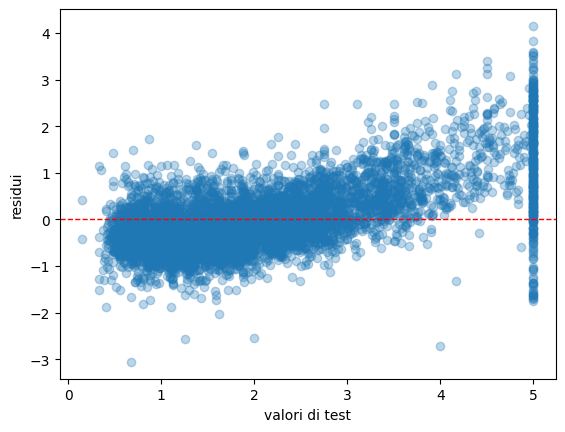

<Figure size 640x480 with 0 Axes>

In [3]:
residuals = y_test - model.predict(X_test_scaled)

import matplotlib.pyplot as plt

plt.scatter(y_test, residuals, alpha=0.3)
plt.xlabel('valori di test')
plt.ylabel('residui')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.show()
plt.clf()

1. Il "Muro" a 5.0 nel Dataset

Nel dataset originale della California, per motivi di privacy o di standardizzazione statistica dell'epoca, tutti i valori delle case superiori a $500.000 sono stati forzatamente arrotondati a 5.0.

    In quel gruppo "5.0" non ci sono solo case da $500k, ma anche ville da $1.000.000 o $2.000.000.​

    Per il dataset, però, valgono tutte esattamente 5.0.​

2. Perché lo spread dei residui aumenta

Il tuo modello di regressione lineare cerca di essere onesto: vede una casa con 10 stanze, in un quartiere ricchissimo sulla costa, e calcola che dovrebbe valere 2.0 ($200k).​

    Calcolo del residuo: Residuo = Valore Reale - Valore Predetto.

    Se la casa è una di quelle "tagliate", il valore reale nel dataset è 5.0.

    Il tuo residuo sarà: 5.0 - 2.0 = \mathbf{+3.0}.​

Ecco perché vedi quei punti schizzare in alto verticalmente proprio quando il valore di test (y_test) è 5.0: sono tutte le case che il modello ha "sottostimato" perché non poteva sapere che erano ville di lusso mascherate da case normali.